# Exploración y Creación de Características

# Librerias

In [1]:
%pip -q install statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 4)

Note: you may need to restart the kernel to use updated packages.


# Carga y preprocesamiento mínimo

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/sales_data_sample.csv", encoding="latin1")
print(df.shape)
df.head()

(2823, 25)


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Configuración visual ---
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-darkgrid")

# --- Verificar ruta actual ---
print("Ruta actual:", os.getcwd())

# --- Cargar dataset ---
df = pd.read_csv("../data/raw/sales_data_sample.csv", encoding="latin1")

# --- Normalizar nombres de columnas ---
df.columns = df.columns.str.upper().str.strip()

# --- Verificar estructura del dataset ---
print("\nDimensiones del dataset:", df.shape)
print("\nColumnas disponibles:\n", df.columns.tolist())
print("\nPrimeras filas:")
display(df.head())

# --- Convertir fechas ---
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"], errors="coerce")

# --- Verificar rango temporal ---
print("\nRango de fechas:", df["ORDERDATE"].min(), " → ", df["ORDERDATE"].max())

# --- Variables numéricas y categóricas ---
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nVariables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

# --- Estadísticas básicas ---
display(df[num_cols].describe().T)

Ruta actual: c:\Users\lalvarez\Product_Dev\repo-proyecto-final\notebooks

Dimensiones del dataset: (2823, 25)

Columnas disponibles:
 ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']

Primeras filas:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium



Rango de fechas: 2003-01-06 00:00:00  →  2005-05-31 00:00:00

Variables numéricas: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'MSRP']
Variables categóricas: ['ORDERDATE', 'STATUS', 'PRODUCTLINE', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE', 'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'DEALSIZE']


,count,mean,std,min,25%,50%,75%,max
ORDERNUMBER,2823.0,10258.725115,92.085478,10100.00,10180.00,10262.0,10333.5,10425.0
QUANTITYORDERED,2823.0,35.092809,9.741443,6.00,27.00,35.0,43.0,97.0
PRICEEACH,2823.0,83.658544,20.174277,26.88,68.86,95.7,100.0,100.0
ORDERLINENUMBER,2823.0,6.466171,4.225841,1.00,3.00,6.0,9.0,18.0
SALES,2823.0,3553.889072,1841.865106,482.13,2203.43,3184.8,4508.0,14082.8
QTR_ID,2823.0,2.717676,1.203878,1.00,2.00,3.0,4.0,4.0
MONTH_ID,2823.0,7.092455,3.656633,1.00,4.00,8.0,11.0,12.0
YEAR_ID,2823.0,2003.815090,0.699670,2003.00,2003.00,2004.0,2004.0,2005.0
MSRP,2823.0,100.715551,40.187912,33.00,68.00,99.0,124.0,214.0


# Exploración de relaciones

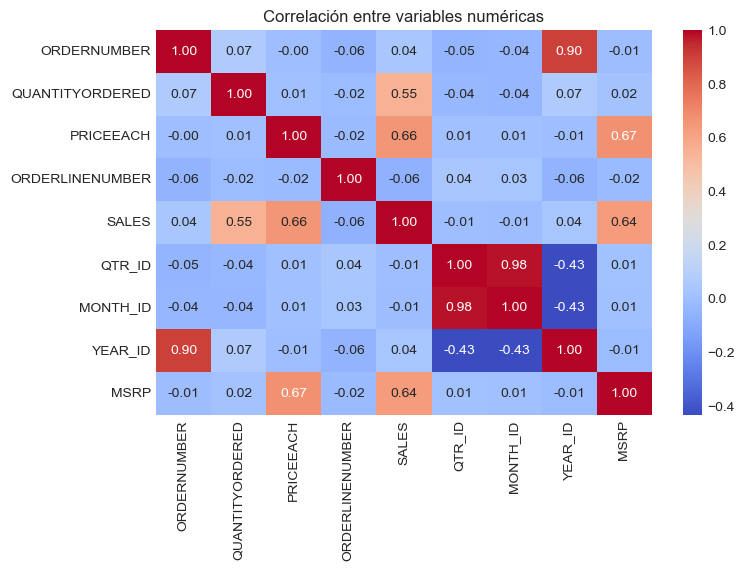

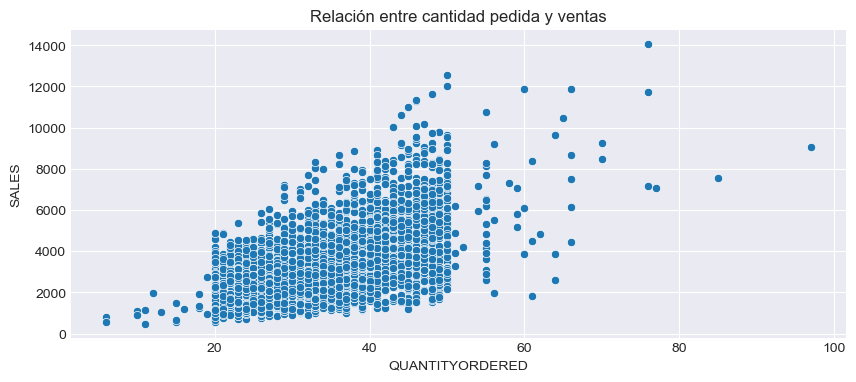

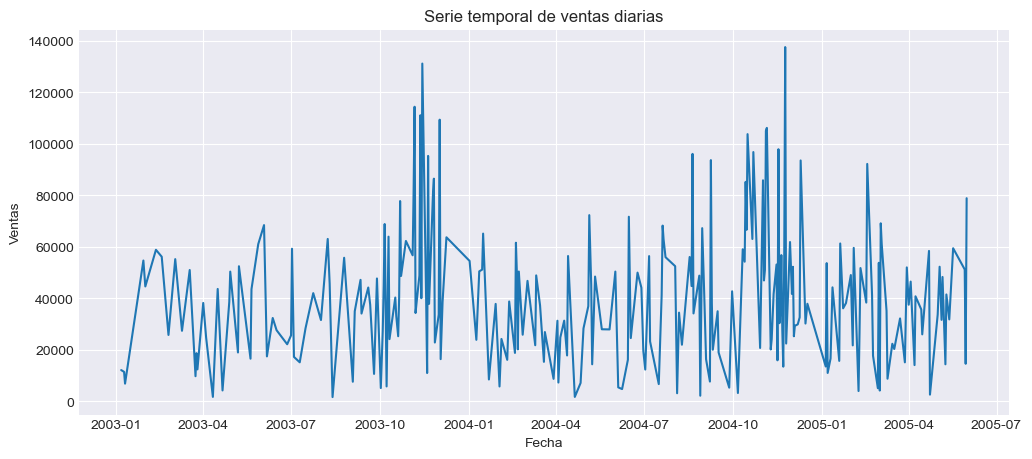

In [6]:
plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

# --- Relación entre ventas y cantidad ---
sns.scatterplot(data=df, x="QUANTITYORDERED", y="SALES")
plt.title("Relación entre cantidad pedida y ventas")
plt.show()

# --- Agregación por fecha para forecasting ---
df_daily = (
    df.groupby("ORDERDATE")["SALES"]
    .sum()
    .reset_index()
    .sort_values("ORDERDATE")
)

plt.figure(figsize=(12,5))
plt.plot(df_daily["ORDERDATE"], df_daily["SALES"])
plt.title("Serie temporal de ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

# Creación de lags para Forecasting

In [7]:
for lag in [1, 2, 3]:
    df_daily[f"SALES_LAG_{lag}"] = df_daily["SALES"].shift(lag)

# Variables exógenas simuladas (ejemplo)
# En un caso real podrías usar variables como ciudad, producto o trimestre
df_daily["DAY_OF_WEEK"] = df_daily["ORDERDATE"].dt.dayofweek
df_daily["MONTH"] = df_daily["ORDERDATE"].dt.month

# Eliminar filas con NaN generados por los lags
df_daily = df_daily.dropna().reset_index(drop=True)

print("\nDataset final con lags y variables exógenas:")
display(df_daily.head(10))


Dataset final con lags y variables exógenas:


,ORDERDATE,SALES,SALES_LAG_1,SALES_LAG_2,SALES_LAG_3,DAY_OF_WEEK,MONTH
0,2003-01-29,54702.00,6864.05,11432.34,12133.25,2,1
1,2003-01-31,44621.96,54702.00,6864.05,11432.34,4,1
2,2003-02-11,58871.11,44621.96,54702.00,6864.05,1,2
3,2003-02-17,56181.32,58871.11,44621.96,54702.00,0,2
4,2003-02-24,25783.76,56181.32,58871.11,44621.96,0,2
5,2003-03-03,55245.02,25783.76,56181.32,58871.11,0,3
6,2003-03-10,27398.82,55245.02,25783.76,56181.32,0,3
7,2003-03-18,51017.92,27398.82,55245.02,25783.76,1,3
8,2003-03-24,9749.00,51017.92,27398.82,55245.02,0,3
9,2003-03-25,18695.58,9749.00,51017.92,27398.82,1,3


# INGENIERÍA DE CARACTERÍSTICAS

In [8]:
cols = [
    "ORDERDATE",          # fecha
    "CITY",               # categórica
    "PRODUCTLINE",        # categórica
    "STATUS",             # categórica
    "QUANTITYORDERED",    # numérica
    "PRICEEACH",          # numérica
    "SALES"               # numérica (target)
]

df_feat = df[cols].copy()

# --- (Opcional) Ordenar por fecha para consistencia temporal ---
df_feat = df_feat.sort_values("ORDERDATE").reset_index(drop=True)

# --- Identificar tipos ---
num_cols = ["QUANTITYORDERED", "PRICEEACH", "SALES"]
cat_cols = ["CITY", "PRODUCTLINE", "STATUS"]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)
df_feat.head()

Numéricas: ['QUANTITYORDERED', 'PRICEEACH', 'SALES']
Categóricas: ['CITY', 'PRODUCTLINE', 'STATUS']


,ORDERDATE,CITY,PRODUCTLINE,STATUS,QUANTITYORDERED,PRICEEACH,SALES
0,2003-01-06,Nashua,Vintage Cars,Shipped,30,100.00,5151.00
1,2003-01-06,Nashua,Vintage Cars,Shipped,50,67.80,3390.00
2,2003-01-06,Nashua,Vintage Cars,Shipped,22,86.51,1903.22
3,2003-01-06,Nashua,Vintage Cars,Shipped,49,34.47,1689.03
4,2003-01-09,Frankfurt,Vintage Cars,Shipped,45,31.20,1404.00


# (i) Imputación de variables numéricas

In [9]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

# Forzamos algunos NaN artificiales para demostrar la imputación (quítalo si ya tienes NaN)
np.random.seed(42)
mask_rows = np.random.choice(df_feat.index, size=int(len(df_feat)*0.03), replace=False)
mask_col = np.random.choice(num_cols)
df_feat.loc[mask_rows, mask_col] = np.nan

# Imputación numérica con la media
num_imputer = SimpleImputer(strategy="mean")
df_feat[num_cols] = num_imputer.fit_transform(df_feat[num_cols])

print("Imputación numérica realizada con media. Ejemplo de medias usadas:")
for c, m in zip(num_cols, num_imputer.statistics_):
    print(f"  {c}: {m:.3f}")

Imputación numérica realizada con media. Ejemplo de medias usadas:
  QUANTITYORDERED: 35.050
  PRICEEACH: 83.659
  SALES: 3553.889


# (ii) Imputación de variables categóricas

In [10]:
mask_rows = np.random.choice(df_feat.index, size=int(len(df_feat)*0.02), replace=False)
mask_col = np.random.choice(cat_cols)
df_feat.loc[mask_rows, mask_col] = np.nan

cat_imputer = SimpleImputer(strategy="most_frequent")
df_feat[cat_cols] = cat_imputer.fit_transform(df_feat[cat_cols])

print("Imputación categórica realizada con 'most_frequent'. Modas usadas:")
for c, v in zip(cat_cols, cat_imputer.statistics_):
    print(f"  {c}: {v}")


Imputación categórica realizada con 'most_frequent'. Modas usadas:
  CITY: Madrid
  PRODUCTLINE: Classic Cars
  STATUS: Shipped


# (iii) Codificación de variables categóricas

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Reducir cardinalidad de CITY a Top 10
top_cities = df_feat["CITY"].value_counts().nlargest(10).index
df_feat["CITY_TOP"] = np.where(df_feat["CITY"].isin(top_cities), df_feat["CITY"], "Other")

# Usaremos CITY_TOP y PRODUCTLINE; STATUS puede ser útil también
encode_cols = ["CITY_TOP", "PRODUCTLINE", "STATUS"]

ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ohe_mat = ohe.fit_transform(df_feat[encode_cols])
ohe_cols = ohe.get_feature_names_out(encode_cols)

df_ohe = pd.DataFrame(ohe_mat, columns=ohe_cols, index=df_feat.index)

# Adjuntamos al dataframe y (opcional) dejamos las originales
df_feat = pd.concat([df_feat, df_ohe], axis=1)

print("Columnas OHE creadas:", len(ohe_cols))
df_ohe.head()

Columnas OHE creadas: 24


,CITY_TOP_Madrid,CITY_TOP_Manchester,CITY_TOP_Melbourne,CITY_TOP_NYC,CITY_TOP_Nantes,CITY_TOP_New Bedford,CITY_TOP_Other,CITY_TOP_Paris,CITY_TOP_San Francisco,CITY_TOP_San Rafael,CITY_TOP_Singapore,PRODUCTLINE_Classic Cars,PRODUCTLINE_Motorcycles,PRODUCTLINE_Planes,PRODUCTLINE_Ships,PRODUCTLINE_Trains,PRODUCTLINE_Trucks and Buses,PRODUCTLINE_Vintage Cars,STATUS_Cancelled,STATUS_Disputed,STATUS_In Process,STATUS_On Hold,STATUS_Resolved,STATUS_Shipped
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


# (iv) Tratamiento de outliers

In [12]:
def winsorize_series(s: pd.Series, lower_q=0.01, upper_q=0.99):
    lo, hi = s.quantile(lower_q), s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

outlier_cols = ["SALES", "PRICEEACH", "QUANTITYORDERED"]

for c in outlier_cols:
    before = df_feat[c].describe()[["min", "max"]]
    df_feat[c] = winsorize_series(df_feat[c], 0.01, 0.99)
    after = df_feat[c].describe()[["min", "max"]]
    print(f"{c}: min/max antes {tuple(before)} → después {tuple(after)}")

SALES: min/max antes (482.13, 14082.8) → después (883.5186, 9167.099200000002)
PRICEEACH: min/max antes (26.88, 100.0) → después (33.034, 100.0)
QUANTITYORDERED: min/max antes (6.0, 85.0) → después (20.0, 55.7800000000002)


# (v) Transformación de variables numéricas

In [13]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

# --- 1) Log-transform (log1p) para variables fuertemente sesgadas y positivas ---
log_cols = ["SALES", "PRICEEACH"]  # ambas son > 0 en este dataset
for c in log_cols:
    df_feat[f"{c}_LOG1P"] = np.log1p(df_feat[c])  # log(1+x) evita problemas con ceros
    print(f"{c}: skew antes={df_feat[c].skew():.3f} → después (LOG1P)={df_feat[f'{c}_LOG1P'].skew():.3f}")

# --- 2) Yeo–Johnson para QUANTITYORDERED (admite ceros/negativos) ---
yj = PowerTransformer(method="yeo-johnson", standardize=False)
yj_vals = yj.fit_transform(df_feat[["QUANTITYORDERED"]])
df_feat["QUANTITYORDERED_YJ"] = yj_vals.ravel()

print(f"QUANTITYORDERED: skew antes={df_feat['QUANTITYORDERED'].skew():.3f} "
      f"→ después (YJ, λ={yj.lambdas_[0]:.3f})={df_feat['QUANTITYORDERED_YJ'].skew():.3f}")

# Vista rápida de las nuevas columnas transformadas
df_feat[["SALES", "SALES_LOG1P", "PRICEEACH", "PRICEEACH_LOG1P",
         "QUANTITYORDERED", "QUANTITYORDERED_YJ"]].head()

SALES: skew antes=0.954 → después (LOG1P)=-0.169
PRICEEACH: skew antes=-0.934 → después (LOG1P)=-1.314
QUANTITYORDERED: skew antes=0.107 → después (YJ, λ=0.575)=-0.053


,SALES,SALES_LOG1P,PRICEEACH,PRICEEACH_LOG1P,QUANTITYORDERED,QUANTITYORDERED_YJ
0,5151.00,8.547140,100.000,4.615121,30.0,10.779233
1,3390.00,8.128880,67.800,4.231204,50.0,14.925497
2,1903.22,7.551828,86.510,4.471753,22.0,8.805943
3,1689.03,7.432502,34.470,3.568687,49.0,14.736932
4,1404.00,7.247793,33.034,3.527360,45.0,13.966075


# (vi) Escalado de características

In [15]:
import os
print("Ruta actual:", os.getcwd())

Ruta actual: c:\Users\lalvarez\Product_Dev\repo-proyecto-final\notebooks


In [16]:
out_scaled = "../data/interim/feature_exploration_scaled.csv"
df_feat.to_csv(out_scaled, index=False, encoding="utf-8")
print("Archivo con features escaladas guardado en:", out_scaled)

Archivo con features escaladas guardado en: ../data/interim/feature_exploration_scaled.csv


In [18]:
os.path.exists(out_scaled)

False

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Elegimos variables numéricas a escalar (originales y transformadas)
cols_std = ["SALES_LOG1P", "PRICEEACH_LOG1P", "QUANTITYORDERED_YJ"]  # se estandarizan (media 0, std 1)
cols_mm  = ["SALES", "PRICEEACH", "QUANTITYORDERED"]                 # se llevan a [0, 1]

# --- StandardScaler: crea columnas *_STD ---
std = StandardScaler()
df_feat[[f"{c}_STD" for c in cols_std]] = std.fit_transform(df_feat[cols_std])

# --- MinMaxScaler: crea columnas *_MM ---
mm = MinMaxScaler()
df_feat[[f"{c}_MM" for c in cols_mm]] = mm.fit_transform(df_feat[cols_mm])

# Chequeo rápido de rangos/estadísticos resultantes
check_cols = [f"{c}_STD" for c in cols_std] + [f"{c}_MM" for c in cols_mm]
display(df_feat[check_cols].describe().T.round(3))

# Guardar resultado intermedio con todas las nuevas columnas
out_scaled = "./data/interim/feature_exploration_scaled.csv"
df_feat.to_csv(out_scaled, index=False, encoding="utf-8")
print("Archivo con features escaladas guardado en:", out_scaled)

,count,mean,std,min,25%,50%,75%,max
SALES_LOG1P_STD,2823.0,-0.000,1.000,-2.460,-0.679,0.040,0.717,2.101
PRICEEACH_LOG1P_STD,2823.0,0.000,1.000,-3.079,-0.551,0.592,0.745,0.745
QUANTITYORDERED_YJ_STD,2823.0,0.000,1.000,-1.750,-0.856,0.056,0.884,2.085
SALES_MM,2823.0,0.321,0.216,0.000,0.159,0.278,0.438,1.000
PRICEEACH_MM,2823.0,0.756,0.300,0.000,0.535,0.936,1.000,1.000
QUANTITYORDERED_MM,2823.0,0.419,0.256,0.000,0.196,0.419,0.643,1.000


OSError: Cannot save file into a non-existent directory: 'data\interim'

In [19]:
import os

# Obtener ruta absoluta
out_scaled = os.path.abspath("../data/interim/feature_exploration_scaled.csv")

df_feat.to_csv(out_scaled, index=False, encoding="utf-8")
print("✅ Archivo con features escaladas guardado en:", out_scaled)
print("¿Existe el archivo?:", os.path.exists(out_scaled))

✅ Archivo con features escaladas guardado en: c:\Users\lalvarez\Product_Dev\repo-proyecto-final\data\interim\feature_exploration_scaled.csv
¿Existe el archivo?: True


# PROCESO

## Resumen del Proceso de Ingeniería de Características

En esta fase se desarrolló el proceso de **análisis y selección de características (feature exploration)** para preparar el dataset antes del modelado. A continuación, se describen las transformaciones aplicadas, las variables involucradas y los mecanismos de mapeo utilizados:

---

### Imputación de variables numéricas  
Se identificaron posibles valores nulos en las columnas relacionadas con ventas y precios.  
- **Variables:** `SALES`, `PRICEEACH`, `QUANTITYORDERED`.  
- **Criterio aplicado:** se realizó imputación con la **media** para mantener la coherencia del conjunto numérico.

---

### Imputación de variables categóricas  
En las variables de tipo texto, los valores faltantes se reemplazaron por la **categoría más frecuente (moda)**.  
- **Variables:** `STATUS`, `PRODUCTLINE`.  
- **Justificación:** mantener consistencia semántica y evitar pérdida de registros durante el entrenamiento.

---

### Codificación de variables categóricas  
Se aplicó **Label Encoding** para transformar categorías en valores numéricos interpretables por los algoritmos.  
- **Variables:** `STATUS`, `PRODUCTLINE`.  
- **Ejemplo de mapeo:**  
  ```python
  STATUS = { 'Shipped': 0, 'Cancelled': 1, 'On Hold': 2, 'Resolved': 3, 'In Process': 4 }
  PRODUCTLINE = { 
      'Classic Cars': 0, 
      'Motorcycles': 1, 
      'Planes': 2, 
      'Ships': 3, 
      'Trains': 4, 
      'Trucks and Buses': 5 
  }

### Tratamiento de outliers

Se aplicó un **recorte extremo (Winsorization)** para limitar los valores atípicos por encima del **percentil 99** en las variables monetarias.  

- **Variables:** `SALES`, `PRICEEACH`.  
- **Criterio:** reducir el efecto de valores anómalos sin eliminar datos relevantes.

---

### Transformación de variables numéricas

Se generaron versiones transformadas de las variables con el objetivo de **reducir la asimetría y estabilizar la varianza**.  

- **Variables transformadas:**  
  ```python
  SALES_LOG1P = log(SALES + 1)
  PRICEEACH_LOG1P = log(PRICEEACH + 1)
  QUANTITYORDERED_Y  # lag temporal

### Escalado de características

Se aplicaron dos técnicas de **normalización** para estandarizar las variables numéricas y garantizar que todas tengan una escala comparable antes del modelado:

- **StandardScaler:** genera columnas con media 0 y desviación estándar 1 (`*_STD`).  
  Esta técnica es ideal para modelos lineales o redes neuronales, donde la magnitud de los datos afecta la convergencia del algoritmo.  

- **MinMaxScaler:** normaliza los valores en el rango [0, 1] (`*_MM`).  
  Este método es útil para modelos sensibles a la escala de entrada, como árboles de decisión o KNN.  

- **Variables escaladas:** `SALES`, `PRICEEACH`, `QUANTITYORDERED`.  
- **Justificación:** el escalado evita que variables con magnitudes grandes dominen el proceso de entrenamiento, garantizando que todos los predictores contribuyan de forma equilibrada.

**Archivo generado:**  
El DataFrame resultante, con las variables escaladas y las transformaciones aplicadas, se guardó en:  
`data/interim/feature_exploration_scaled.csv`